# Proyecto 1: Explorando Datos del Mundo Real con Python

**Carrera:** Tecnicatura Universitaria en Tecnologías de Programación

**Materia:** Programación Python Avanzada

**Integrantes:** Olivera Yohana y Urriola Itziar

**Dataset:** Juegos de la tienda Steam 

**Fuente:** Kaggle.com

**Link Dataset:** https://www.kaggle.com/datasets/nikdavis/steam-store-games

**Link Repositorio GitHub:** https://github.com/YohaOlivera/Proyecto1_Olivera_Urriola_UPSO-Salliquelo

## Análisis exploratorio del catálogo de videojuegos de Steam (1997–2019)

### Descripción del dataset

Este dataset proporciona información detallada sobre los juegos disponibles en la tienda de Steam, creada a partir de datos recopilados mediante las API de Steam Store y SteamSpy. Contiene un registro de 27.075 filas y 18 columnas abarcando videojuegos desde inicio del 1997 hasta mediados del 2019.
La base recopila variables comerciales e identificatorias (nombre, fecha de lanzamiento, desarrollador, editor y precio de venta base), especificaciones técnicas (compatibilidad de sistemas operativos y géneros), y métricas de recepción comunitaria (recuento de reseñas positivas y negativas, cantidad de logros y tiempos promedio de juego registrados por los usuarios).


### Justificación de la elección

Se eligió este dataset porque además de cumplir con las condiciones que se piden para este proyecto,
nos resulto interesante analizar este dataset sobre videojuegos ya que es un hobbie que compartimos entre ambas.


### Preguntas de investigación

Al analizar el contenido del dataset, nos surgieron las siguientes preguntas para responder con los datos del dataset:

1. ¿Que genero de videojuego concentra el mayor porcentaje promedio de reseñas positivas por parte de los usuarios? 

2. ¿Existen una relación directa o correlación lineal entre el precio de un videojuego y el nivel de satisfacción de los jugadores?

3. ¿En que período anual se produjo la mayor aceleración histórica en la cantidad de lanzamientos dentro de la plataforma Steam?

### Diccionario de variables

| Columna | Tipo de Dato | Descripción |
|--------|--------------|-------------|
| Id juego | int64 | Identificador único del videojuego en la plataforma Steam. |
| Nombre | str | Título oficial del videojuego. |
| Fecha de lanzamiento | str | Fecha en la que el juego fue publicado en la tienda. |
| Idioma ingles | int64 | Variable binaria: 1 si el juego incluye soporte para idioma inglés, 0 en caso contrario. |
| Desarrollador | str | Estudio o persona creadora del videojuego. |
| Editor | str | Empresa encargada de la publicación y distribución comercial del título. |
| Plataformas | str | Sistemas operativos compatibles (ej. windows, mac, linux). |
| Edad requerida | int64 | Edad mínima recomendada o restricción de edad oficial. |
| Categorias | str | Modos de juego y características técnicas (ej. Single-player, Multi-player). |
| Generos | str | Clasificación temática principal del juego (ej. Action, Adventure, Indie). |
| Etiquetas SteamSpy | str | Etiquetas asignadas por la comunidad de jugadores en la plataforma SteamSpy. |
| Logros | int64 | Cantidad total de logros (achievements) desbloqueables en el juego. |
| Valoraciones positivas | int64 | Cantidad total de reseñas positivas recibidas por parte de los usuarios. |
| Valoraciones negativas | int64 | Cantidad total de reseñas negativas recibidas por parte de los usuarios. |
| Tiempo promedio de juego | int64 | Tiempo promedio de juego registrado por los usuarios (expresado en minutos). |
| Tiempo medio de juego | int64 | Mediana del tiempo de juego de la base de usuarios (expresado en minutos). |
| Propietarios | str | Rango estimado de usuarios que poseen el juego en su biblioteca. |
| Precio | float64 | Precio de venta base original (en Libras Esterlinas - GBP). |

### Desarrollo

#### Importación de librerías y exploración inicial

In [67]:
# Importamos las librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset
df_original = pd.read_csv("steam.csv")

Generamos una copia del dataset para hacer el análisis sin alterar los datos originales.

In [68]:
df = df_original.copy()

Transformamos los nombres de las columnas al español, para facilitar el uso y el análisis

In [69]:
nuevos_nombres = {
    "appid": "Id juego",
    "name": "Nombre",
    "release_date": "Fecha de lanzamiento",
    "developer": "Desarrollador",
    "publisher": "Editor",
    "platforms": "Plataformas",
    "required_age": "Edad requerida",
    "categories": "Categorias",
    "genres": "Generos",
    "achievements": "Logros",
    "positive_ratings": "Valoraciones positivas",
    "negative_ratings": "Valoraciones negativas",
    "average_playtime": "Tiempo promedio de juego",
    "median_playtime": "Tiempo medio de juego",
    "owners": "Propietarios",
    "price": "Precio",
    "english": "Idioma ingles",
    "steamspy_tags": "Etiquetas SteamSpy"
}

df = df.rename(columns=nuevos_nombres)

print(df.columns.tolist())
df.head()

['Id juego', 'Nombre', 'Fecha de lanzamiento', 'Idioma ingles', 'Desarrollador', 'Editor', 'Plataformas', 'Edad requerida', 'Categorias', 'Generos', 'Etiquetas SteamSpy', 'Logros', 'Valoraciones positivas', 'Valoraciones negativas', 'Tiempo promedio de juego', 'Tiempo medio de juego', 'Propietarios', 'Precio']


,Id juego,Nombre,Fecha de lanzamiento,Idioma ingles,Desarrollador,Editor,Plataformas,Edad requerida,Categorias,Generos,Etiquetas SteamSpy,Logros,Valoraciones positivas,Valoraciones negativas,Tiempo promedio de juego,Tiempo medio de juego,Propietarios,Precio
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


Utilizamos **`.shape[ ]`** para conocer las dimensiones del dataset, es decir cuantas filas y columnas tiene.

In [70]:
print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas")

Dimensiones del dataset: 27075 filas y 18 columnas


Con el método **`.info( )`** obtenemos el nombre de las columnas, un conteo de valores NO nulos y el tipo de dato que contiene cada columna.

In [71]:
print("Información general y tipos de datos:")
df.info()

Información general y tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id juego                  27075 non-null  int64  
 1   Nombre                    27075 non-null  str    
 2   Fecha de lanzamiento      27075 non-null  str    
 3   Idioma ingles             27075 non-null  int64  
 4   Desarrollador             27074 non-null  str    
 5   Editor                    27061 non-null  str    
 6   Plataformas               27075 non-null  str    
 7   Edad requerida            27075 non-null  int64  
 8   Categorias                27075 non-null  str    
 9   Generos                   27075 non-null  str    
 10  Etiquetas SteamSpy        27075 non-null  str    
 11  Logros                    27075 non-null  int64  
 12  Valoraciones positivas    27075 non-null  int64  
 13  Valoraciones negativas    27075 no

En la información anterior notamos que:

* Las columnas "Desarrollador" y "Editor" no contienen la totalidad de los datos, por lo cual inferimos que hay valores nulos. Para comprobarlo ejecutamos el siguiente código:

In [72]:
# Mostramos las columnas con valores nulos
print("Columnas con valores nulos:")
nulos = df.isnull().sum()
nulos[nulos > 0]

Columnas con valores nulos:


Desarrollador     1
Editor           14
dtype: int64

Calculamos que porcentaje representan estos valores sobre el total de los datos.

In [73]:
# Mostramos el porcentaje de valores nulos por columna
print("Porcentaje de valores nulos (%):")
porcentaje_nulos = (nulos[nulos > 0] / len(df)) * 100
porcentaje_nulos.round(4)

Porcentaje de valores nulos (%):


Desarrollador    0.0037
Editor           0.0517
dtype: float64

Exploramos de manera inicial las estadísticas de las variables numéricas

In [74]:
print("Estadísticas dscriptivas de variables numéricas:")
df.describe()

Estadísticas dscriptivas de variables numéricas:


,Id juego,Idioma ingles,Edad requerida,Logros,Valoraciones positivas,Valoraciones negativas,Tiempo promedio de juego,Tiempo medio de juego,Precio
count,2.707500e+04,27075.000000,27075.000000,27075.000000,2.707500e+04,27075.000000,27075.000000,27075.00000,27075.000000
mean,5.962035e+05,0.981127,0.354903,45.248864,1.000559e+03,211.027147,149.804949,146.05603,6.078193
std,2.508942e+05,0.136081,2.406044,352.670281,1.898872e+04,4284.938531,1827.038141,2353.88008,7.874922
min,1.000000e+01,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000
25%,4.012300e+05,1.000000,0.000000,0.000000,6.000000e+00,2.000000,0.000000,0.00000,1.690000
50%,5.990700e+05,1.000000,0.000000,7.000000,2.400000e+01,9.000000,0.000000,0.00000,3.990000
75%,7.987600e+05,1.000000,0.000000,23.000000,1.260000e+02,42.000000,0.000000,0.00000,7.190000
max,1.069460e+06,1.000000,18.000000,9821.000000,2.644404e+06,487076.000000,190625.000000,190625.00000,421.990000


**Conclusión sobre la calidad de datos:**

* Como muestra la exploración inicial el dataset es robusto ya que cuenta con un total de 27.075 registros. 
* Los tipos de datos son coherentes con la información que representan en la mayoría de las columnas, aunque variables como la "Fecha de lanzamiento" requieren transformación a formato datetime para su correcto análisis temporal. 
* A nivel de completitud, consideramos que tiene una alta calidad, únicamente se detectaron valores nulos en las columnas categóricas "Desarrollador" (1 nulo) y "Editor" (14 nulos). Al representar un porcentaje ínfimo respecto al total (menos del 0,05%), requerirán un tratamiento de limpieza menor sin comprometer la integridad del análisis general.

#### Variables Categóricas y Numéricas a analizar

Para poder dar respuesta a las preguntas de investigación que nos planteamos en este proyecto, seleccionamos las siguientes variables clave:

* **Variables Numéricas:**
    * **Precio:** Es la variable principal para analizar si el costo monetario guarda relación con la recepción del público
    * **Valoraciones positivas y negativas:** Ambas variables son necesarias para construir una métrica de satisfacción del usuario y medir el porcentaje de aceptación.

* **Variables Categóricas:**
    * **Genero:** Esta variable resulta imprescindible para clasificar el catálogo y descubrir qué tipo de juegos concentra las mejores reseñas.
    * **Fecha de lanzamiento:** Clave para evaluar el crecimiento histórico del catálogo y detectar el período de mayor aceleración de publicaciones.
    * **Plataformas:** Esta variable nos permite segmentar el mercado permitiendo evaluarel impacto del soporte multiplataforma en relación a las politicas de precios y en la satisfacción de los usuarios.

#### Transformaciones y limpieza de datos

* **Manejo de valores faltantes**

Al inspeccionar el dataset, detectamos valores nulos en dos columanas.Como representan un porcentaje minusculo (0,0037 y 0,0517)tomamos la decisión de eliminar estas filas, ya que imputar los datos con otros valores no genera un aporte significativo al análisis

In [75]:
# Eliminamos las filas con nulos en Desarollador y Editor
df = df.dropna(subset=["Desarrollador", "Editor"]).copy()

# Comprobamos las nuevas dimensiones 
print(f"Dimensiones del dataset tras eliminar nulos: {df.shape}")

Dimensiones del dataset tras eliminar nulos: (27061, 18)


* **Limpieza y creacion de nuevas columnas**

Para responder nuestras preguntas de investigación, realizamos las siguientes transformaciones:

* **Género principal:** En el dataset los juegos tienen múltiples géneros separados por punto y coma (ej: Action;Adventure). Extraeremos solo el primero para categorizarlos mejor.

In [76]:
# Eliminamos los espacios en blanco de la columna "Generos"
df["Generos"] = df["Generos"].astype(str).str.strip()

# Extraemos el genero principal
df["Genero principal"] = df["Generos"].str.split(";").str[0].str.strip()

# Ver los generos principales más comunes
print("Distribucion de generos principales:")
df["Genero principal"].value_counts().head(10)

Distribucion de generos principales:


Genero principal
Action            11205
Adventure          5254
Casual             4371
Indie              2622
Violent             708
Simulation          630
Strategy            532
RPG                 407
Free to Play        395
Sexual Content      245
Name: count, dtype: int64

* **Plataformas:** Separamos en columnas binarias cada una de las plataformas, ya que nos permite hacer cálculos.

In [77]:
# Creamos nuevas columnas binarias para cada plataforma
df["Plataforma Windows"] = df["Plataformas"].str.contains("windows", case=False).astype(int)
df["Plataforma Mac"] = df["Plataformas"].str.contains("mac", case=False).astype(int)
df["Plataforma Linux"] = df["Plataformas"].str.contains("linux", case=False).astype(int)

# Creamos una nueva columna que cuente la cantidad de plataformas disponibles para cada juego
df["Cantidad plataformas"] = df["Plataforma Windows"] + df["Plataforma Mac"] + df["Plataforma Linux"]

# Verificación
df[["Nombre", "Plataformas", "Plataforma Windows", "Plataforma Mac", "Plataforma Linux", "Cantidad plataformas"]].head()

,Nombre,Plataformas,Plataforma Windows,Plataforma Mac,Plataforma Linux,Cantidad plataformas
0,Counter-Strike,windows;mac;linux,1,1,1,3
1,Team Fortress Classic,windows;mac;linux,1,1,1,3
2,Day of Defeat,windows;mac;linux,1,1,1,3
3,Deathmatch Classic,windows;mac;linux,1,1,1,3
4,Half-Life: Opposing Force,windows;mac;linux,1,1,1,3


* **Precios en USD:** Transformaremos la moneda original (GBP) a dólares asumiendo una tasa de cambio fija aproximada (1 GBP = 1.30 USD).

In [78]:
tasa_cambio_gbp_usd = 1.30
df["Precio usd"] = (df["Precio"] * tasa_cambio_gbp_usd).round(2)

df.info()

<class 'pandas.DataFrame'>
Index: 27061 entries, 0 to 27074
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id juego                  27061 non-null  int64  
 1   Nombre                    27061 non-null  str    
 2   Fecha de lanzamiento      27061 non-null  str    
 3   Idioma ingles             27061 non-null  int64  
 4   Desarrollador             27061 non-null  str    
 5   Editor                    27061 non-null  str    
 6   Plataformas               27061 non-null  str    
 7   Edad requerida            27061 non-null  int64  
 8   Categorias                27061 non-null  str    
 9   Generos                   27061 non-null  str    
 10  Etiquetas SteamSpy        27061 non-null  str    
 11  Logros                    27061 non-null  int64  
 12  Valoraciones positivas    27061 non-null  int64  
 13  Valoraciones negativas    27061 non-null  int64  
 14  Tiempo promedio de jue

* **índice de satidfacción:** Calculamos la proporción de valoraciones positivas sobre el total de valoraciones: Positivas / (Positivas + Negativas).

In [79]:
total_valoraciones = df['Valoraciones positivas'] + df['Valoraciones negativas']

# Creamos la columna vacía
df['Indice de satisfaccion'] = np.nan

# Calculamos solo donde hay votos registrados
con_votos = total_valoraciones > 0
df.loc[con_votos, 'Indice de satisfaccion'] = (
    df.loc[con_votos, 'Valoraciones positivas'] / total_valoraciones[con_votos]
).round(4)

# Verificación
df[["Nombre", "Valoraciones positivas", "Valoraciones negativas", "Indice de satisfaccion"]].head()

,Nombre,Valoraciones positivas,Valoraciones negativas,Indice de satisfaccion
0,Counter-Strike,124534,3339,0.9739
1,Team Fortress Classic,3318,633,0.8398
2,Day of Defeat,3416,398,0.8956
3,Deathmatch Classic,1273,267,0.8266
4,Half-Life: Opposing Force,5250,288,0.9480


Para facilitar la comprensión conveetimos en porcentaje el índice de valoración

In [80]:
df["Porcentaje satisfaccion"] = np.nan
con_votos = total_valoraciones > 0

df.loc[con_votos, "Porcentaje satisfaccion"] = (
    (df.loc[con_votos, "Valoraciones positivas"] / total_valoraciones.loc[con_votos]) * 100
).round(2)

# Verificación
df[["Nombre", "Valoraciones positivas", "Valoraciones negativas", "Porcentaje satisfaccion"]].head()

,Nombre,Valoraciones positivas,Valoraciones negativas,Porcentaje satisfaccion
0,Counter-Strike,124534,3339,97.39
1,Team Fortress Classic,3318,633,83.98
2,Day of Defeat,3416,398,89.56
3,Deathmatch Classic,1273,267,82.66
4,Half-Life: Opposing Force,5250,288,94.80


* **Rango de precios:** Clasificamos los juegos en Gratis (0 USD), Económico (hasta 10 USD), Estándar(hasta 30 USD) y Premium (más de 30 USD) usando la función `pd.cut`. 

In [81]:
# Definimos los intervalos de precios
intervalos_precio = [-0.01, 0.01, 10.0, 30.0, df["Precio usd"].max() + 1]

# Definimos las etiquetas para cada rango de precios
labels_precio = ["Gratis", "Económico", "Estándar", "Premium"]

# Creamos la nueva columna "Rango de precio" usando pd.cut
df["Rango de precio"] = pd.cut(df["Precio usd"], bins=intervalos_precio, labels=labels_precio, right=False)

# Verificación
df[["Nombre", "Precio usd", "Rango de precio"]].head()

,Nombre,Precio usd,Rango de precio
0,Counter-Strike,9.35,Económico
1,Team Fortress Classic,5.19,Económico
2,Day of Defeat,5.19,Económico
3,Deathmatch Classic,5.19,Económico
4,Half-Life: Opposing Force,5.19,Económico


* **Año de lanzamiento:** Para extraer solo el año de la fecha completa, primero convertimos la columna "Fecha de lanzamiento" de `str` a `datetime`, y luego creamos la nueva columna solo con el año de lanzamiento.

In [82]:
# Convertimos a datetime la columna "Fecha de lanzamiento"
df["Fecha de lanzamiento"] = pd.to_datetime(df["Fecha de lanzamiento"])

# Extraemos el año de lanzamiento y lo almacenamos en una nueva columna
df["Año de lanzamiento"] = df["Fecha de lanzamiento"].dt.year

# Verificación
df[["Nombre", "Fecha de lanzamiento", "Año de lanzamiento"]].head()

,Nombre,Fecha de lanzamiento,Año de lanzamiento
0,Counter-Strike,2000-11-01,2000
1,Team Fortress Classic,1999-04-01,1999
2,Day of Defeat,2003-05-01,2003
3,Deathmatch Classic,2001-06-01,2001
4,Half-Life: Opposing Force,1999-11-01,1999


* **Agrupación por variable categorica**

A continuación, agruparemos los datos para empezar a visualizar tendencias, como la satisfacción por rango de precio o el crecimiento de lanzamientos año a año.

**Promedio de satisfacción por Género Principal**

In [83]:
agrupacion_genero = df.groupby("Genero principal")["Indice de satisfaccion"].mean().sort_values(ascending=False)

# Verificación
agrupacion_genero.head(10)

Genero principal
Software Training        0.965000
Web Publishing           0.905600
Design & Illustration    0.775196
RPG                      0.747909
Animation & Modeling     0.744202
Adventure                0.739871
Sexual Content           0.730213
Indie                    0.724066
Action                   0.716164
Education                0.713500
Name: Indice de satisfaccion, dtype: float64

**Cantidad de juegos por Plataforma**

In [84]:
agrupacion_plataforma = df.groupby("Plataformas")["Id juego"].count().sort_values(ascending=False)

# Verificación
agrupacion_plataforma.head(10)

Plataformas
windows              18387
windows;mac;linux     4622
windows;mac           3438
windows;linux          609
mac                      3
mac;linux                1
linux                    1
Name: Id juego, dtype: int64

**Satisfacción promedio segun rango de precio**

In [85]:
agrupacion_precio = df.groupby('Rango de precio', observed=True)['Indice de satisfaccion'].mean()

# verificación
agrupacion_precio.head(10)

Rango de precio
Gratis       0.719124
Económico    0.700849
Estándar     0.754994
Premium      0.743948
Name: Indice de satisfaccion, dtype: float64

**Cantidad de lanzamientos por año y diferencia porcentual**

In [86]:
lanzamientos_por_ano = df.groupby('Año de lanzamiento').size().reset_index(name='Cantidad de lanzamientos')

# Se calcula el % de cambio con respecto a la fila anterior
lanzamientos_por_ano['Diferencia porcentual %'] = (lanzamientos_por_ano['Cantidad de lanzamientos'].pct_change() * 100).round(2)

# Verificación
lanzamientos_por_ano.head(10)


,Año de lanzamiento,Cantidad de lanzamientos,Diferencia porcentual %
0,1997,1,NaN
1,1998,1,0.0
2,1999,2,100.0
3,2000,2,0.0
4,2001,4,100.0
5,2002,1,-75.0
6,2003,3,200.0
7,2004,6,100.0
8,2005,6,0.0
9,2006,48,700.0


**Conclusión de Transformaciones y Agrupaciones**

La limpieza y transformación nos permitió aislar variables clave. La creación del "Índice de satisfacción" unifica las valoraciones positivas y negativas en una sola métrica porcentual más justa de comparar. Por su parte, la agrupación temporal y el cálculo de la "Diferencia porcentual anual" ya nos anticipan un salto masivo en la cantidad de juegos publicados alrededor de 2014, lo cual será fundamental para responder a nuestra tercera pregunta de investigación en la etapa de visualización.

#### Operaciones con NumPy

Si bien se realizaron operaciones con NumPy en las secciones anteriores, por ejemplo en la converción de los precios de GBP a USD, en este apartado nos enfocaremos en la exploración y normalización de variables numéricas utilizando las herramientas que nos brinda Numpy. 
Para lograrlo, transformaremos las variables numéricas principales (Precio usd, Valoraciones positivas y Valoraciones negativas) en arrays y desarrollaremos una función estadística propia. Esta función automatizará el cálculo de métricas de tendencia central y dispersión, incorporando el filtrado de valores nulos. Finalmente, aplicaremos un escalado lineal (Min-Max) para normalizar los precios.

In [87]:
# Conversión de variables numéricas a arrays de numpy 
arr_precio = df["Precio usd"].to_numpy()
arr_positivas = df["Valoraciones positivas"].to_numpy()
arr_negativas = df["Valoraciones negativas"].to_numpy()

# Función para automatizar metricas descriptivas
def calcular_metricas_numpy(arr, nombre = "Variable"):
    datos = arr[~np.isnan(arr)]

    media = np.mean(datos)
    mediana = np.median(datos)
    desviacion = np.std(datos)
    p25 = np.percentile(datos, 25)
    p75 = np.percentile(datos, 75)
    iqr = p75 - p25
    minimo = np.min(datos)
    maximo = np.max(datos)

    return pd.Series({
        "Variable": nombre,
        "Media": round(media, 2),
        "Mediana": round(mediana, 2),
        "Desviación estándar": round(desviacion, 2),
        "Percentil 25": round(p25, 2),
        "Percentil 75": round(p75, 2),
        "IQR": round(iqr, 2),
        "Mínimo": round(minimo, 2),
        "Máximo": round(maximo, 2)
    })

# Resumen estadístico
tabla_numpy = pd.DataFrame([
    calcular_metricas_numpy(arr_precio, "Precio en USD"),
    calcular_metricas_numpy(arr_positivas, "Valoraciones Positivas"),
    calcular_metricas_numpy(arr_negativas, "Valoraciones Negativas")
])

tabla_numpy.head()

,Variable,Media,Mediana,Desviación estándar,Percentil 25,Percentil 75,IQR,Mínimo,Máximo
0,Precio en USD,7.91,5.19,10.24,2.2,9.35,7.15,0.0,548.59
1,Valoraciones Positivas,1001.04,24.00,18993.27,6.0,126.00,120.00,0.0,2644404.00
2,Valoraciones Negativas,211.12,9.00,4285.97,2.0,42.00,40.00,0.0,487076.00


**Normalización de las variables**

In [88]:
# Normalización Min-Max de la variable Precio usd al rango [0, 1]
min_val = np.min(arr_precio)
max_val = np.max(arr_precio)
df["Precio_usd_norm"] = (arr_precio - min_val) / (max_val - min_val)

# Verificación
df[["Nombre", "Precio usd", "Precio_usd_norm"]].head()

,Nombre,Precio usd,Precio_usd_norm
0,Counter-Strike,9.35,0.017044
1,Team Fortress Classic,5.19,0.009461
2,Day of Defeat,5.19,0.009461
3,Deathmatch Classic,5.19,0.009461
4,Half-Life: Opposing Force,5.19,0.009461


**Conlusión**

Los resultados de nuestra función revelan una fuerte asimetría en los datos de Steam. En las valoraciones, notamos que la media es muchísimo mayor que la mediana, con una desviación estándar enorme y máximos exorbitantes. Esto indica que hay un pequeño grupo de juegos que son extremadamente populares y concentran la gran mayoría de las reseñas, mientras que el 75% del catálogo apenas supera las 126 reseñas positivas. En cuanto al precio, la normalización nos permite observar la distribución en una escala estándar, confirmando que la mayoría del catálogo se sitúa muy cerca del límite inferior, es decir, la mayoría de los juegos se situan en el rango de precios "económicos", siendo muy raros los títulos que se acercan al valor 1 de nuestra escala normalizada, es decir al rango de juegos "premium".

#### Visualización de datos

En esta sección, generaremos visualizaciones clave para entender la distribución de nuestros datos y responder a las preguntas de investigación planteadas al inicio del proyecto utilizando `matplotlib` y `seaborn`.

In [ ]:
# Definimos tema claro para los gráficos
sns.set_theme(style="whitegrid", palette="muted")

##### **Visualización 1: Análisis de Precios**

Antes de graficar la distribución general de los precios, necesitamos entender si existen valores extremos (outliers). Para ello, aplicamos un gráfico Boxplot para visualizarlos.

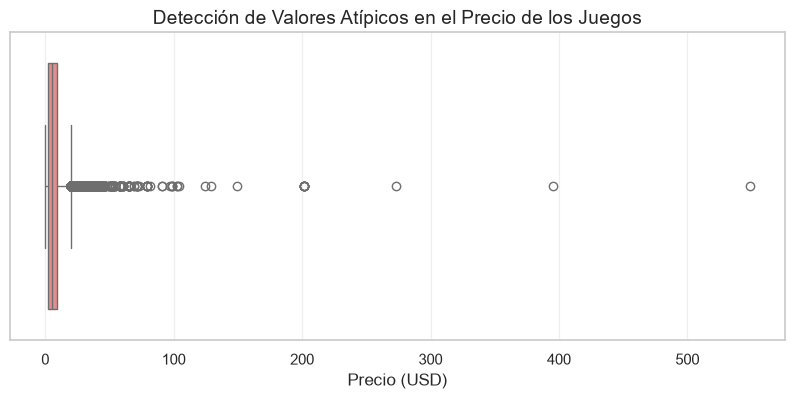

In [95]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df['Precio usd'], color='lightcoral')
plt.title('Detección de Valores Atípicos en el Precio de los Juegos', fontsize=14)
plt.xlabel('Precio (USD)')
plt.show()

**Conclusión:** Como revela el Boxplot superior, la inmensa mayoría de los juegos cuestan menos de 50 USD. Sin embargo, existen valores atípicos extremos que superan los 400 USD. Si incluimos estos valores en un histograma, el gráfico se comprimiría tanto que no podríamos ver la distribución real. 
Por esta razón, **filtraremos el dataset a juegos con un precio menor o igual a 100 USD**, lo que representa más del 99% de nuestro catálogo.

Ahora analizaremos como se distribuyen los precios del catálogo completo, teniendo en cuenta lo anteriormente mencionado.

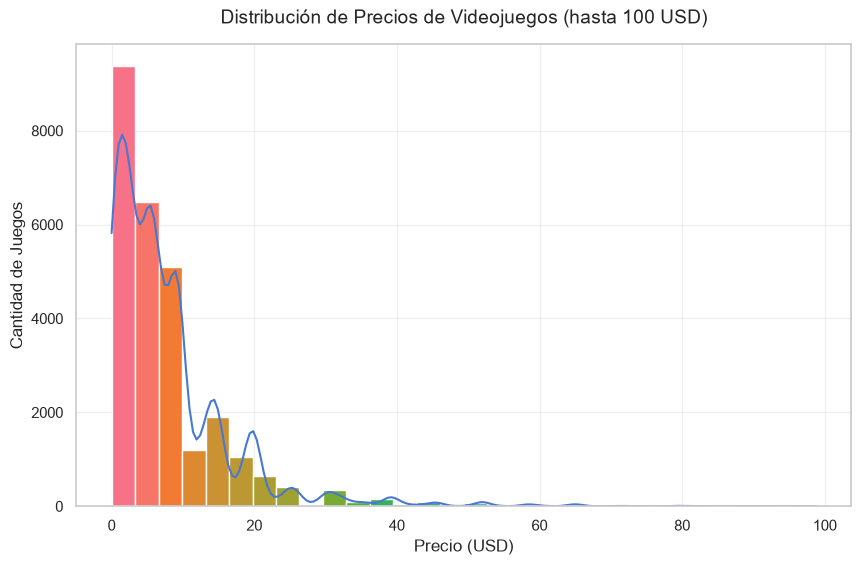

In [100]:
plt.figure(figsize=(10, 6))

# Filtramos los juegos de más de 100USD para que no se deforme el gráfico
precios_filtrados = df[df["Precio usd"] <= 100]

# Creamos el histograma 
ax = sns.histplot(data=precios_filtrados, x='Precio usd', bins=30, kde=True)

# Configuramos paleta de colores
paleta_hist = sns.color_palette("husl", len(ax.patches))
for i, barra in enumerate(ax.patches):
    barra.set_facecolor(paleta_hist[i % len(paleta_hist)])

plt.title('Distribución de Precios de Videojuegos (hasta 100 USD)', fontsize=14, pad=15)
plt.xlabel('Precio (USD)', fontsize=12)
plt.ylabel('Cantidad de Juegos', fontsize=12)
plt.show()

**Interpretación:** Como podemos comprobar con el gráfico la inmensa mayoría de los títulos en Steam se concentran en el rango de los $0 a $10 USD. La distribución está fuertemente sesgada a la derecha, indicando que los juegos con precios altos o "Premium" son una minoría en el volumen total del catálogo.

##### **Visualización 2: Satisfacción por Género**

**Pregunta de investigación 1: ¿Qué género de videojuego concentra el mayor porcentaje promedio de reseñas positivas por parte de los usuarios?**

Para evitar que géneros con solo 2 o 3 juegos distorsionen el promedio con puntuaciones perfectas, filtraremos el análisis para incluir únicamente aquellos géneros que tengan un mínimo de 100 juegos publicados.

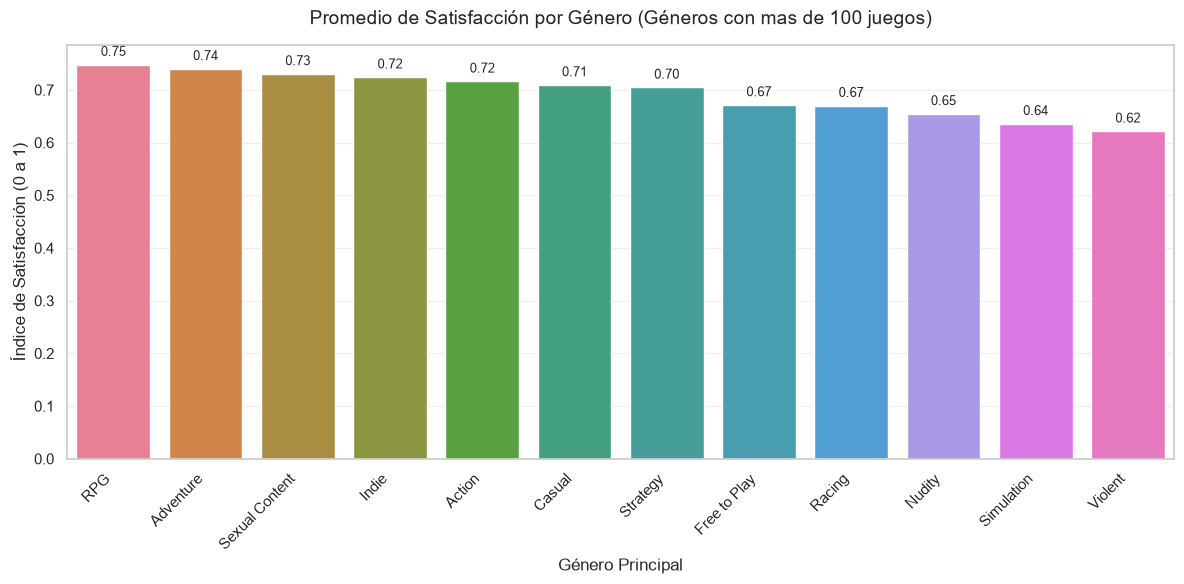

In [102]:
plt.figure(figsize=(12, 6))

# Conteo de generos principales
conteo_generos = df['Genero principal'].value_counts()

# Filtramos géneros con más de 100 juegos
generos_populares = conteo_generos[conteo_generos > 100].index

# Creamos un nuevo DataFrame con los géneros populares
df_generos = df[df['Genero principal'].isin(generos_populares)]

# Calculamos el promedio de satisfacción por género
satisfaccion_genero = df_generos.groupby('Genero principal')['Indice de satisfaccion'].mean().reset_index()

# Ordenamos de mayor a menor
satisfaccion_genero = satisfaccion_genero.sort_values(by='Indice de satisfaccion', ascending=False)

# Creamos el gráfico de barras
ax = sns.barplot(data=satisfaccion_genero, x='Genero principal', y='Indice de satisfaccion', hue='Genero principal', palette='husl', legend=False)

plt.title('Promedio de Satisfacción por Género (Géneros con mas de 100 juegos)', fontsize=14, pad=15)
plt.xlabel('Género Principal', fontsize=12)
plt.ylabel('Índice de Satisfacción (0 a 1)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Añadir etiquetas de datos sobre las barras
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

**Pregunta de investigación 1: ¿Qué género de videojuego concentra el mayor porcentaje promedio de reseñas positivas por parte de los usuarios?**

**Respuesta:** A partir del análisis comparativo, se determina que el género que lidera el nivel de satisfacción comunitaria en la plataforma es RPG, alcanzando un índice promedio de 0.75, escoltado inmediatamente por Adventure (0.74). Aunque el conjunto general de categorías exhibe un comportamiento favorable con registros que oscilan entre 0.62 y 0.75, los datos revelan que los juegos con fuerte componente narrativo y bases de usuarios fidelizadas logran una mejor valoración que aquellos dependientes de modelos masivos como Free to Play (0.67) o de simulación técnica como Simulation (0.64), los cuales enfrentan mayores exigencias y fricciones por parte de la comunidad.

##### **Visualización 3: Relación entre Precio y Satisfacción**

**Pregunta de investigación 2: ¿Existe una relación directa o correlación lineal entre el precio de un videojuego y el nivel de satisfacción de los jugadores?**

Para abordar esta pregunta, comenzamos con una exploración visual directa mediante un gráfico de dispersión (Scatter Plot). Graficamos cada juego como un punto individual. 

`*Nota analítica:*` Para evitar que el gráfico se deforme, excluimos los títulos que superan los 60 USD, ya que este es el precio máximo histórico estándar para lanzamientos "AAA" (superproducciones) en Steam, y representan la inmensa mayoría del mercado real como lo comprobamos con el histograma y boxplot del gráfico 1.

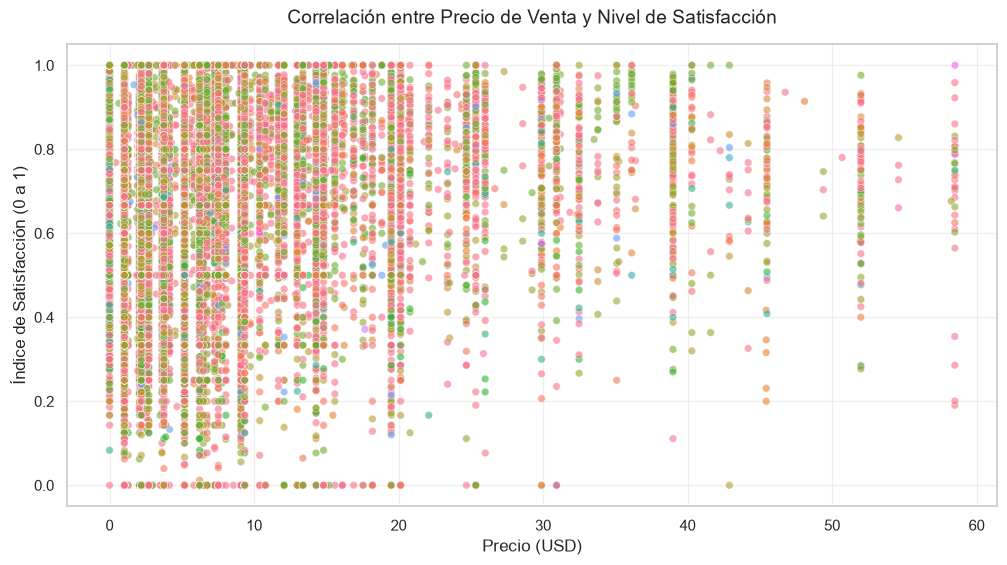

In [103]:
plt.figure(figsize=(12, 6))

df_scatter = df[df['Precio usd'] <= 60]

# Mapeamos el color por género para mantener la estética colorida en los puntos
sns.scatterplot(data=df_scatter, x='Precio usd', y='Indice de satisfaccion', 
                hue='Genero principal', palette='husl', alpha=0.6, s=30, legend=False)

plt.title('Correlación entre Precio de Venta y Nivel de Satisfacción', fontsize=14, pad=15)
plt.xlabel('Precio (USD)', fontsize=12)
plt.ylabel('Índice de Satisfacción (0 a 1)', fontsize=12)
plt.show()

**Confirmación Estadística:** Como se observa en el gráfico anterior, la densidad de los datos hace que sea complicado identificar a simple vista si existe una tendencia ascendente o descendente. Para eliminar la ambigüedad visual y obtener una respuesta definitiva, recurriremos a un **Mapa de Calor (Heatmap) de correlación de Pearson**. Esta herramienta matemática cruzará el precio y la satisfacción (junto con otras variables numéricas) devolviéndonos un valor exacto entre -1 (correlación inversa) y 1 (correlación directa perfecta).

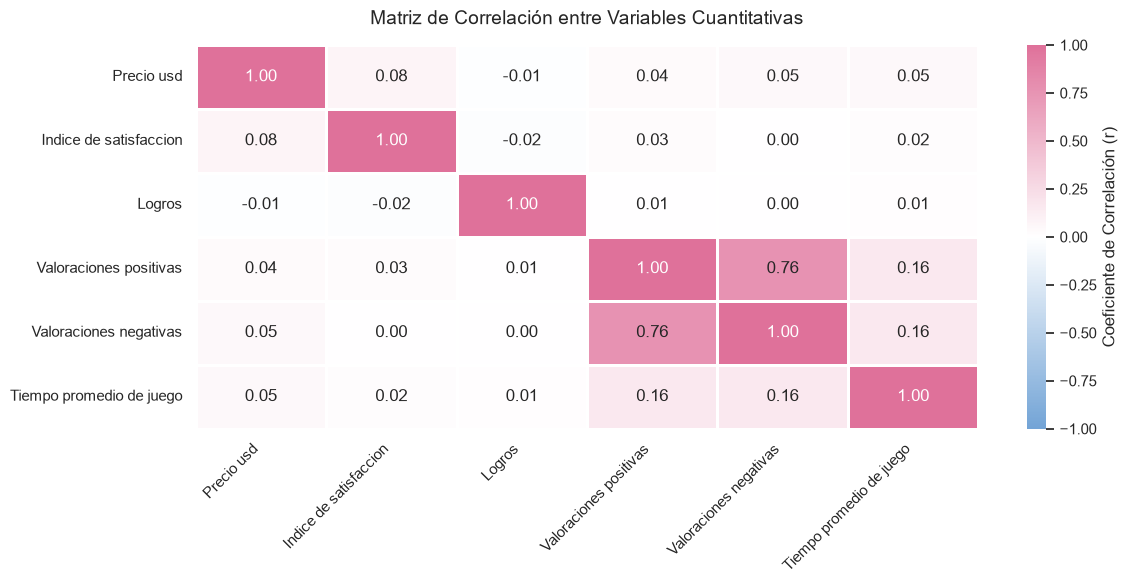

In [ ]:
# Importamos la clase LinearSegmentedColormap para crear un mapa de colores personalizado
from matplotlib.colors import LinearSegmentedColormap

plt.figure(figsize=(12, 6))

# Seleccionamos las variables numéricas clave para la matriz
columnas_interes = [
    'Precio usd', 
    'Indice de satisfaccion', 
    'Logros', 
    'Valoraciones positivas', 
    'Valoraciones negativas', 
    'Tiempo promedio de juego'
]

# Calculamos la matriz de correlación de Pearson
matriz_correlacion = df[columnas_interes].corr()

# Definimos paleta de colores
color_negativo = '#73A4D6'  
color_neutro = '#FFFFFF'    
color_positivo = '#DF719A'  

# Creamos una variable para la paleta de colores 
mi_gradiente = LinearSegmentedColormap.from_list('custom_cmap', [color_negativo, color_neutro, color_positivo])

# Generamos el Heatmap
sns.heatmap(
    matriz_correlacion, 
    annot=True, 
    fmt='.2f', 
    cmap=mi_gradiente, 
    vmin=-1, 
    vmax=1, 
    linewidths=0.8,
    cbar_kws={'label': 'Coeficiente de Correlación (r)'}
)

plt.title('Matriz de Correlación entre Variables Cuantitativas', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Pregunta de investigación 2: ¿Existe una relación directa o correlación lineal entre el precio de un videojuego y el nivel de satisfacción de los jugadores?**

**Respuesta:** Como pudimos observar en el gráfico de dispersión (Scatter Plot) los puntos forman una nube plana sin una dirección clara. Esto es validado estadísticamente por el Mapa de Calor, el cual arroja un coeficiente de Pearson de **0.08** al cruzar ambas variables. La combinación de la exploración visual y la matriz matemática confirma de manera contundente que **no existe una relación lineal directa entre el precio de un videojuego y el nivel de satisfacción de los jugadores**. Los jugadores de Steam evalúan los juegos en función de sus propias expectativas y del valor entregado, no de lo que pagaron. Es posible encontrar juegos gratuitos con altísima aceptación y juegos de precio premium (60 USD) con reseñas mayoritariamente negativas.

##### **Visualización 4: Evolución de Lanzamientos**

**Pregunta de investigación 3: ¿En qué período anual se produjo la mayor aceleración histórica en la cantidad de lanzamientos dentro de la plataforma Steam?**

`*Nota analítica:*` En la siguiente visualización decidimos mantener el año 2019. Sin embargo, es fundamental aclarar que el dataset finaliza su recolección de datos a mediados de dicho año. Por consiguiente, la drástica caída que se observa al final de la serie temporal es una "falsa caída" producto de datos incompletos, y no representa una contracción real de las publicaciones en la plataforma.

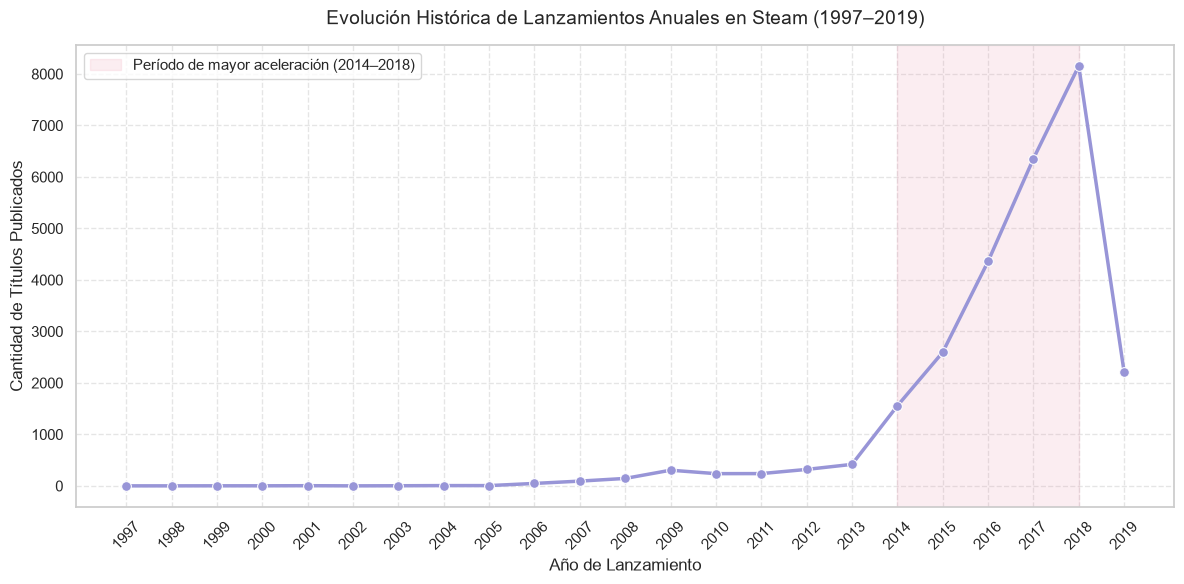

In [111]:
plt.figure(figsize=(12, 6))

# Agrupamos por año y contamos la cantidad de títulos
lanzamientos_anuales = df.groupby('Año de lanzamiento').size().reset_index(name='Cantidad de lanzamientos')

# Extraemos colores de la paleta 
color_linea = "#9895D7"    
color_sombreado = "#E98BA6"

# Gráfico de línea temporal
sns.lineplot(
    data=lanzamientos_anuales, 
    x='Año de lanzamiento', 
    y='Cantidad de lanzamientos', 
    marker='o', 
    color=color_linea, 
    linewidth=2.5,
    markersize=7
)

plt.title('Evolución Histórica de Lanzamientos Anuales en Steam (1997–2019)', fontsize=14, pad=15)
plt.xlabel('Año de Lanzamiento', fontsize=12)
plt.ylabel('Cantidad de Títulos Publicados', fontsize=12)
plt.xticks(lanzamientos_anuales['Año de lanzamiento'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Destacar el período de aceleración exponencial (2014-2018)
plt.axvspan(2014, 2018, color=color_sombreado, alpha=0.15, label='Período de mayor aceleración (2014–2018)')
plt.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()


**Pregunta de investigación 3: ¿En qué período anual se produjo la mayor aceleración histórica en la cantidad de lanzamientos dentro de la plataforma Steam?**

**Respuesta:** El gráfico de tendencia evidencia claramente que la mayor aceleración histórica se produjo **entre los años 2014 y 2018** (área sombreada). Durante esos cuatro años, la curva rompe su crecimiento moderado previo y se vuelve exponencial. Este salto masivo en la publicación de títulos coincide directamente con la implementación de políticas de distribución abierta por parte de Valve (como Steam Direct), democratizando y facilitando el acceso de desarrolladores independientes a la tienda global.

#### Conlusiones

#### Exportación de resultados